In [2]:
import torch, pandas, numpy, sklearn, IPython

print("Torch:", torch.__version__)
print("Pandas:", pandas.__version__)
print("Numpy:", numpy.__version__)
print("Sklearn:", sklearn.__version__)
print("IPython:", IPython.__version__)


Torch: 2.6.0
Pandas: 2.2.2
Numpy: 1.26.4
Sklearn: 1.6.1
IPython: 8.27.0


In [ ]:
import sys
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from IPython.display import display
#đổi đường dẫn này theo thư mục của bạn
sys.path.append('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/scripts/ncf-utils')
from utils import Utils, EarlyStopping, cols_dict
from model import NCF

sys.path.append('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/scripts/ncf-utils')
pd.set_option("display.max_columns", 6)
import os
os.makedirs("weights", exist_ok=True)


In [ ]:
print("🔹 Loading data...") #đổi đường dẫn này theo thư mục của bạn
ratings_data = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/ratings.dat', 
                           sep='::', names=cols_dict['ratings'], engine='python')
users_data = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/users.dat', 
                         sep='::', names=cols_dict['users'], engine='python')
items_data = pd.read_csv('/Users/chi.nguyenth/Documents/DoAn_63133022_NguyenThiHaChi/dataset/1m/movies.dat', 
                         sep='::', names=cols_dict['items'], encoding='latin-1', engine='python')

print("✅ Data loaded.")
print("Ratings data (3 rows):")
display(ratings_data.head(3))

print("Users data (3 rows):")
display(users_data.head(3))

print("Items data (3 rows):")
display(items_data.head(3))

print("Ratings shape:", ratings_data.shape)
print("Users shape:", users_data.shape)
print("Items shape:", items_data.shape)


🔹 Loading data...
✅ Data loaded.
Ratings data (3 rows):


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


Users data (3 rows):


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117


Items data (3 rows):


,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


Ratings shape: (1000209, 4)
Users shape: (6040, 5)
Items shape: (3883, 3)


In [11]:
# --- BACKUP ORIGINAL DATA ---
users_data_og = users_data.copy()
items_data_og = items_data.copy()
ratings_data_og = ratings_data.copy()

In [12]:
print("🔎 Checking for missing values...")
print("Ratings nulls:", ratings_data.isnull().sum().sum())
print("Users nulls:", users_data.isnull().sum().sum())
print("Items nulls:", items_data.isnull().sum().sum())


🔎 Checking for missing values...
Ratings nulls: 0
Users nulls: 0
Items nulls: 0


In [13]:

# One-hot encode gender and occupation for users
print("🔹 One-hot encoding users' gender and occupation...")
users_data = Utils.one_hot_encode(users_data, ['occupation', 'gender', 'age'])

# Multi-hot encode genres for items
print("🔹 Multi-hot encoding items' genres...")
items_data = Utils.multi_hot_encode(items_data, 'genre')

# Display a sample of transformed data
print("Users data after encoding:")
display(users_data.head(3))

print("Items data after encoding:")
display(items_data.head(3))


🔹 One-hot encoding users' gender and occupation...
🔹 Multi-hot encoding items' genres...
Users data after encoding:


,user_id,zip_code,occupation_0,...,age_45,age_50,age_56
0,1,48067,0,...,0,0,0
1,2,70072,0,...,0,0,1
2,3,55117,0,...,0,0,0


Items data after encoding:


,movie_id,title,Action,...,Thriller,War,Western
0,1,Toy Story (1995),0,...,0,0,0
1,2,Jumanji (1995),0,...,0,0,0
2,3,Grumpier Old Men (1995),0,...,0,0,0


In [14]:
users_data = Utils.extract_category_avg_ratings(users_data, items_data, ratings_data)
items_data = Utils.extract_year(items_data)
users_data = Utils.move_column(users_data, ['gender_M', 'gender_F'], 0)
# --- ALIGN USERS & ITEMS ---
users_data, items_data = Utils.extend_users_items(users_data, items_data, ratings_data)


In [15]:
# --- DROP UNUSED COLUMNS ---
ratings_data = ratings_data.drop(['timestamp'], axis=1)
users_data = users_data.drop(['user_id', 'zip_code'], axis=1)
items_data = items_data.drop(['movie_id', 'title'], axis=1)

In [16]:
# --- NORMALIZATION ---
ratings_data['rating'] = ratings_data['rating'] / 5.0
items_data['year'] = items_data['year'] / items_data['year'].max()
users_data.iloc[:, -18:] = users_data.iloc[:, -18:] / users_data.iloc[:, -18:].max().max()

# --- SPLIT DATA ---
X_users_train, X_users_test = train_test_split(users_data, test_size=0.2, random_state=42)
X_users_val, X_users_test = train_test_split(X_users_test, test_size=0.5, random_state=42)

X_items_train, X_items_test = train_test_split(items_data, test_size=0.2, random_state=42)
X_items_val, X_items_test = train_test_split(X_items_test, test_size=0.5, random_state=42)

y_ratings_train, y_ratings_test = train_test_split(ratings_data, test_size=0.2, random_state=42)
y_ratings_val, y_ratings_test = train_test_split(y_ratings_test, test_size=0.5, random_state=42)

# --- CONVERT TO NUMPY ---
X_users_train, X_users_val, X_users_test = X_users_train.values, X_users_val.values, X_users_test.values
X_items_train, X_items_val, X_items_test = X_items_train.values, X_items_val.values, X_items_test.values
y_ratings_train, y_ratings_val, y_ratings_test = y_ratings_train.values, y_ratings_val.values, y_ratings_test.values

In [17]:
print("X_items_test:")
print(X_items_test)

print("\nX_items_train:")
print(X_items_train)

print("\nX_items_val:")
print(X_items_val)

print("\nX_users_test:")
print(X_users_test)

print("\nX_users_train:")
print(X_users_train)

print("\nX_users_val:")
print(X_users_val)

print("\ncols_dict:")
print(cols_dict)

print("\ndir:")
print(dir)

print("\nitems_data:")
print(items_data)

print("\nratings_data:")
print(ratings_data)

print("\nusers_data:")
print(users_data)

print("\ny_ratings_test:")
print(y_ratings_test)

print("\ny_ratings_train:")
print(y_ratings_train)

print("\ny_ratings_val:")
print(y_ratings_val)

X_items_test:
[[0.     0.     0.     ... 0.     0.     0.996 ]
 [0.     0.     0.     ... 0.     0.     0.9995]
 [0.     0.     0.     ... 0.     1.     0.9825]
 ...
 [1.     1.     0.     ... 0.     0.     0.9935]
 [0.     0.     0.     ... 0.     0.     0.9985]
 [0.     0.     0.     ... 0.     0.     0.993 ]]

X_items_train:
[[0.     0.     0.     ... 1.     0.     0.9775]
 [0.     0.     0.     ... 0.     0.     0.9995]
 [1.     0.     0.     ... 0.     0.     0.9965]
 ...
 [0.     0.     0.     ... 0.     0.     0.9925]
 [0.     1.     0.     ... 0.     0.     0.9925]
 [1.     0.     0.     ... 1.     0.     0.998 ]]

X_items_val:
[[0.     0.     0.     ... 0.     0.     0.9915]
 [0.     0.     0.     ... 0.     0.     0.9975]
 [0.     1.     0.     ... 0.     0.     0.9885]
 ...
 [0.     0.     0.     ... 0.     0.     0.9955]
 [1.     0.     0.     ... 0.     0.     0.9895]
 [0.     0.     0.     ... 0.     0.     0.996 ]]

X_users_test:
[[1.         0.         1.         ... 0.

In [18]:
# --- MODEL SETUP ---
user_dim = users_data.shape[1]
item_dim = items_data.shape[1]
num_users = users_data_og['user_id'].max()
num_items = items_data_og['movie_id'].max()

model = NCF(
    num_users=num_users,
    num_items=num_items,
    user_dim=user_dim,
    item_dim=item_dim,
    num_factors=32,
    mode='explicit',
    criterion=torch.nn.MSELoss(),
    dropout=0.1,
    lr=1e-3,
    weight_decay=1e-5,
    verbose=True,
    gpu=True
)

NCF(
  (user_embedding_mlp): Embedding(6041, 32)
  (item_embedding_mlp): Embedding(3953, 32)
  (user_embedding_mf): Embedding(6041, 32)
  (item_embedding_mf): Embedding(3953, 32)
  (user_features): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (item_features): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (MLP): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=128, out_features=32, bias=True)
    (10): ReLU

Epoch 1/12
391/391 - loss: 0.0356 - Val Loss: 0.0326 - R2: 0.3506 - MAE: 0.1428 - MSE: 0.0326 - RMSE: 0.1806 - lr: 0.001
Epoch 2/12
391/391 - loss: 0.0316 - Val Loss: 0.0309 - R2: 0.3856 - MAE: 0.1393 - MSE: 0.0309 - RMSE: 0.1757 - lr: 0.001
Epoch 3/12
391/391 - loss: 0.0300 - Val Loss: 0.0301 - R2: 0.4009 - MAE: 0.1377 - MSE: 0.0301 - RMSE: 0.1735 - lr: 0.001
Epoch 4/12
391/391 - loss: 0.0290 - Val Loss: 0.0297 - R2: 0.4077 - MAE: 0.1356 - MSE: 0.0298 - RMSE: 0.1725 - lr: 0.001
Epoch 5/12
391/391 - loss: 0.0283 - Val Loss: 0.0293 - R2: 0.4163 - MAE: 0.1353 - MSE: 0.0293 - RMSE: 0.1712 - lr: 0.001
Epoch 6/12
391/391 - loss: 0.0278 - Val Loss: 0.0297 - R2: 0.4086 - MAE: 0.1361 - MSE: 0.0297 - RMSE: 0.1723 - lr: 0.0001
Epoch 7/12
391/391 - loss: 0.0257 - Val Loss: 0.0291 - R2: 0.4199 - MAE: 0.1339 - MSE: 0.0291 - RMSE: 0.1707 - lr: 0.0001
Epoch 8/12
391/391 - loss: 0.0252 - Val Loss: 0.0290 - R2: 0.4217 - MAE: 0.1334 - MSE: 0.0290 - RMSE: 0.1704 - lr: 0.0001
Epoch 9/12
391/391 - loss: 0.

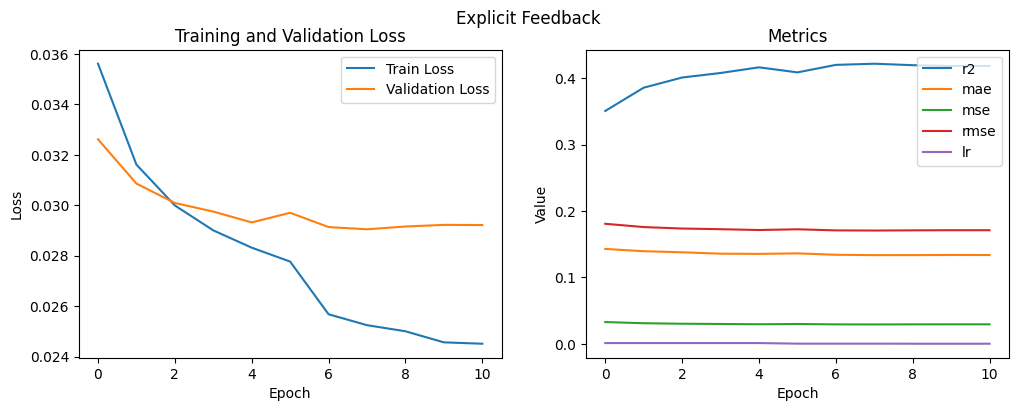

In [ ]:
early_stopping = EarlyStopping(patience=3, delta=0.0002, path='weights/explicit.pth')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(model.optimizer, mode='min', factor=0.1, patience=0)

history = model.fit(
    X=[y_ratings_train[:, 0], y_ratings_train[:, 1], X_users_train, X_items_train],
    y=y_ratings_train[:, 2],
    X_val=[y_ratings_val[:, 0], y_ratings_val[:, 1], X_users_val, X_items_val],
    y_val=y_ratings_val[:, 2],
    epochs=12,
    batch_size=2048,
    early_stopping=early_stopping,
    scheduler=scheduler
)

Utils.plot_metrics(history, 'Explicit Feedback')

In [20]:
# --- Step 6: Model Evaluation ---
print("🔹 Evaluating model on test data...")

model.eval() # Set model to evaluation mode (disables dropout layers)

with torch.no_grad():
    user_ids = torch.tensor(y_ratings_test[:, 0], dtype=torch.long).to(model.device)
    item_ids = torch.tensor(y_ratings_test[:, 1], dtype=torch.long).to(model.device)
    user_features = torch.tensor(X_users_test, dtype=torch.float32).to(model.device)
    item_features = torch.tensor(X_items_test, dtype=torch.float32).to(model.device)
    
    # predict
    y_pred = model(user_ids, item_ids, user_features, item_features)
    y_pred = y_pred.cpu().numpy()


🔹 Evaluating model on test data...


In [21]:
# Đưa dữ liệu thực và dự đoán vào DataFrame
results_df = pd.DataFrame({
    'user_id': y_ratings_test[:, 0],
    'movie_id': y_ratings_test[:, 1],
    'true_rating': y_ratings_test[:, 2],
    'predicted_rating': y_pred.flatten()
})

# Scale lại
results_df['true_rating'] = results_df['true_rating'] * 5
results_df['predicted_rating'] = results_df['predicted_rating'] * 5

# Làm tròn và chuyển thành số nguyên
results_df['predicted_rating'] = results_df['predicted_rating'].round().astype(int)

# Nếu muốn true_rating cũng thành số nguyên:
results_df['true_rating'] = results_df['true_rating'].round().astype(int)

# Xem kết quả
display(results_df.head(10))


,user_id,movie_id,true_rating,predicted_rating
0,2857.0,2268.0,4,4
1,1172.0,2710.0,3,2
2,5376.0,3681.0,5,4
3,4362.0,246.0,5,4
4,2197.0,246.0,4,4
5,4117.0,1729.0,4,4
6,5952.0,541.0,4,4
7,456.0,912.0,3,4
8,5636.0,65.0,1,1
9,2241.0,936.0,5,4


In [22]:
results_df['abs_error'] = abs(results_df['true_rating'] - results_df['predicted_rating'])
mae = results_df['abs_error'].mean()
print(f"MAE: {mae:.4f}")

MAE: 0.6241


In [24]:
# Tính MAE
results_df['abs_error'] = abs(results_df['true_rating'] - results_df['predicted_rating'])
mae = results_df['abs_error'].mean()
print(f"MAE: {mae:.4f}")

# Tính RMSE
from sklearn.metrics import mean_squared_error
import numpy as np
mse = mean_squared_error(results_df['true_rating'], results_df['predicted_rating'])
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.4f}")


MAE: 0.6241
RMSE: 0.9046


1. Các cách xử lý user mới (Cold Start):
- Dùng sở thích khai báo khi đăng ký: đơn giản, hiệu quả thấp.

- Dùng trung bình embedding của tất cả user: đơn giản, hiệu quả thấp.

- Thêm 1 embedding đặc biệt cho user mới: đơn giản, hiệu quả thấp.

- Dùng session-based model (BST, GRU4Rec): phức tạp, hiệu quả cao.

- Lấy trung bình embedding của user tương tự (cosine similarity): đơn giản, hiệu quả tốt.

New User (age: 25, gender: M, likes: Comedy, Action)

=> Tính vector đặc trưng.

=> So sánh với 10000 user cũ => tìm ra 10 user giống nhất (theo cosine similarity)

=> Lấy embedding của 10 user đó -> tính trung bình -> ra embedding của new user

=> Dùng embedding đó để predict top 10 phim.


In [19]:
new_user = {
    'id': 7000, # new user id
    'age': 20,
    'occupation': 'engineer',
    'gender': 'F',
    'genres': ['Children', 'Comedy', 'Animation'],
}

user_id, user, weights, _ = Utils.preprocess_user(
                                user=new_user,
                                num_items=items_data_og.shape[0],
                                users=users_data.drop_duplicates(inplace=False).values,
                                weights=[model.user_embedding_mlp.weight.data.cpu().numpy(), model.user_embedding_mf.weight.data.cpu().numpy()]
                                )
items = Utils.preprocess_items(items_data_og)

user_id, user = user_id.to(model.device), user.to(model.device)

In [20]:
# 1- Retrieval Stage
movies = Utils.retrieve(
    movies=items,
    user=user.detach().cpu().numpy(),
    num_genres=3,
    k=300, # retrieve 300 relevant movies. Note: higher k leads to better recommendations but slower inference
    random_state=0
)

# 2- Filtering Stage
movie_ids, movies = Utils.filter( # Removes already-rated / duplicate movies
    movies=movies,
    ratings=ratings_data_og,
    user_id=new_user['id']
)
movie_ids, movies = movie_ids.to(model.device), movies.to(model.device)

# 3- Ranking Stage
y_pred = model(
    user_id[:len(movies)],
    movie_ids,
    user[:len(movies)],
    movies,
    weights
).cpu().detach().numpy()

# 4- Ordering Stage
movies_retrieved = items_data_og[items_data_og['movie_id'].isin(movie_ids.cpu().numpy())].sort_values(by='movie_id', key=lambda x: pd.Categorical(x, categories=movie_ids.cpu().numpy(), ordered=True))
Utils.order(y_pred, movies_retrieved, 'explicit', top_k=10)

,movie_id,title,genre,predicted_rating
0,720,Wallace & Gromit: The Best of Aardman Animatio...,Animation,4.73
1,1148,"Wrong Trousers, The (1993)",Animation|Comedy,4.67
2,3114,Toy Story 2 (1999),Animation|Children's|Comedy,4.61
3,3396,"Muppet Movie, The (1979)",Children's|Comedy,4.50
4,1,Toy Story (1995),Animation|Children's|Comedy,4.47
5,1223,"Grand Day Out, A (1992)",Animation|Comedy,4.45
6,595,Beauty and the Beast (1991),Animation|Children's|Musical,4.44
7,1136,Monty Python and the Holy Grail (1974),Comedy,4.42
8,2355,"Bug's Life, A (1998)",Animation|Children's|Comedy,4.40
9,3429,Creature Comforts (1990),Animation|Comedy,4.40


In [21]:
old_user = {
    'id': 400
}

# preprocess the old user
user_id, user, _, _ = Utils.preprocess_user(
                                user=old_user,
                                num_items=items_data_og.shape[0],
                                users=users_data.drop_duplicates(inplace=False).values,
                                topk=3, # top 3 genres the user has interacted with. MAX: 18
                                verbose=True
                                )
items = Utils.preprocess_items(items_data_og)

user_id, user = user_id.to(model.device), user.to(model.device)


User id: 400 top 3 genres: ['Thriller' 'Action' 'Adventure']


In [22]:
# 1- Retrieval Stage
movies = Utils.retrieve(
    movies=items,
    user=user.detach().cpu().numpy(),
    k=300, # retrieve 300 relevant movies. Note: higher k leads to better recommendations but slower inference
    random_state=0
)

# 2- Filtering Stage
movie_ids, movies = Utils.filter( # Removes already-rated / duplicate movies
    movies=movies,
    ratings=ratings_data_og,
    user_id=new_user['id']
)
movie_ids, movies = movie_ids.to(model.device), movies.to(model.device)

# 3- Ranking Stage
y_pred = model(
    user_id[:len(movies)],
    movie_ids,
    user[:len(movies)],
    movies
).cpu().detach().numpy()

# 4- Ordering Stage
movies_retrieved = items_data_og[items_data_og['movie_id'].isin(movie_ids.cpu().numpy())].sort_values(by='movie_id', key=lambda x: pd.Categorical(x, categories=movie_ids.cpu().numpy(), ordered=True))
Utils.order(y_pred, movies_retrieved, 'eplicit', top_k=10)

,movie_id,title,genre,predicted_score
0,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.53
1,110,Braveheart (1995),Action|Drama|War,4.47
2,733,"Rock, The (1996)",Action|Adventure|Thriller,4.35
3,180,Mallrats (1995),Comedy,4.27
4,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Romance,4.22
5,1479,"Saint, The (1997)",Action|Romance|Thriller,4.21
6,3510,Frequency (2000),Drama|Thriller,4.16
7,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.15
8,2263,"Seventh Sign, The (1988)",Thriller,4.13
9,1620,Kiss the Girls (1997),Crime|Drama|Thriller,4.12
